In [2]:
import os

# Pega aquí adentro el código que acabas de copiar de Kaggle
# Deja las comillas simples, solo borra lo de adentro y pega tu llave
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_eb1af4c929780c5aa275673ed1dfbe92'

print("¡Pasaporte de Kaggle configurado en la memoria de Colab!")

¡Pasaporte de Kaggle configurado en la memoria de Colab!


In [3]:
# 1. Descargamos el dataset CORRECTO y limpio de ESC-50
!kaggle datasets download -d eliasmarcon/environmental-sound-classification-50

# 2. Descomprimimos el archivo zip en la carpeta 'esc50_data'
import zipfile
print("Descargando y descomprimiendo el dataset correcto... Dame un momento.")

with zipfile.ZipFile("environmental-sound-classification-50.zip", "r") as zip_ref:
    zip_ref.extractall("esc50_data")

print("¡Ahora sí, listo el pollo! Dataset original y limpio en 'esc50_data'.")

Dataset URL: https://www.kaggle.com/datasets/eliasmarcon/environmental-sound-classification-50
License(s): MIT
100% 615M/615M [00:05<00:00, 117MB/s]

Descargando y descomprimiendo el dataset correcto... Dame un momento.
¡Ahora sí, listo el pollo! Dataset original y limpio en 'esc50_data'.


In [5]:
import pandas as pd

# Cargamos el CSV con las etiquetas desde la carpeta descomprimida
df = pd.read_csv('esc50_data/ESC-50-master/esc50_labels.csv')

# Definimos nuestras tres analogías físicas subacuáticas
clases_submarino = ['sea_waves', 'rain', 'helicopter']

# Filtramos el dataframe original para quedarnos solo con estas categorías
df_filtrado = df[df['category'].isin(clases_submarino)].reset_index(drop=True)

# Mapeamos las clases de texto a números enteros para que la IA pueda procesarlas (0, 1, 2)
mapeo = {'sea_waves': 0, 'rain': 1, 'helicopter': 2}
df_filtrado['label_num'] = df_filtrado['category'].map(mapeo)

print("¡Estructura filtrada con éxito!")
print(f"Total de muestras que usaremos para entrenar: {len(df_filtrado)}")
print("\nCantidad de audios por categoría:")
print(df_filtrado['category'].value_counts())

¡Estructura filtrada con éxito!
Total de muestras que usaremos para entrenar: 120

Cantidad de audios por categoría:
category
helicopter    40
rain          40
sea_waves     40
Name: count, dtype: int64


Transformando ondas de sonido en matrices de frecuencia... Dale un momento.
Estructura de datos lista para la CNN: (64, 157, 1)
¡Empezando el entrenamiento de la Inteligencia Artificial!



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.3333 - loss: 1.1420 - val_accuracy: 0.4583 - val_loss: 1.0800
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5104 - loss: 1.0559 - val_accuracy: 0.2500 - val_loss: 1.0810
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5208 - loss: 1.0234 - val_accuracy: 0.2500 - val_loss: 1.2015
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4688 - loss: 0.9720 - val_accuracy: 0.2917 - val_loss: 1.1612
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4792 - loss: 0.9486 - val_accuracy: 0.5833 - val_loss: 0.9188
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5521 - loss: 0.8532 - val_accuracy: 0.5417 - val_loss: 1.0449
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6042 - loss: 0.8139 - val_accuracy: 0.2500 - val_loss: 1.0504
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6562 - loss: 0.7530 - val_accuracy: 0.7917 - v

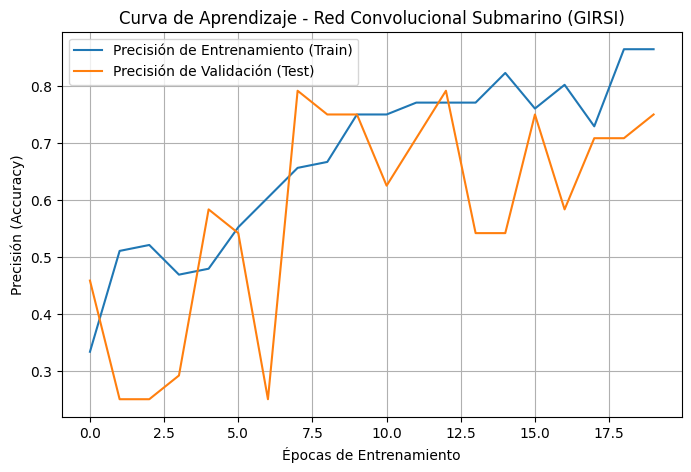

In [11]:
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = []
y = []

print("Transformando ondas de sonido en matrices de frecuencia... Dale un momento.")

# Recorremos el dataframe filtrado para procesar los audios uno a uno
for idx, row in df_filtrado.iterrows():
    # Construimos la ruta exacta usando la carpeta que encontraste
    ruta_audio = f"esc50_data/ESC-50-master/{row['filename']}"

    # Cargamos el audio forzando 16kHz para asegurar compatibilidad futura con tu hardware
    audio, sr = librosa.load(ruta_audio, sr=16000)

    # Extracción del Espectrograma de Mel (La "foto" de la vibración)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    X.append(mel_spec_db)
    y.append(row['label_num'])

# Convertimos a arreglos numéricos de NumPy y normalizamos los datos
X = np.array(X)
y = np.array(y)
X = (X - X.min()) / (X.max() - X.min()) # Valores entre 0 y 1 para facilitar el cálculo matemático
X = X[..., np.newaxis] # Añadimos la dimensión de canal para la CNN (Matriz 2D -> 3D)

# Separamos los datos de manera aleatoria (80% Entrenamiento, 20% Validación)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Estructura de datos lista para la CNN: {X_train.shape[1:]}")
print("¡Empezando el entrenamiento de la Inteligencia Artificial!\n")

# --- ARQUITECTURA DE LA RED NEURONAL CONVOLUCIONAL (CNN) ---
model = models.Sequential([
    # Primera capa convolucional: escanea los patrones del espectrograma
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
    layers.MaxPooling2D((2, 2)),

    # Segunda capa convolucional: detecta combinaciones de frecuencias complejas
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Capa de aplanado y clasificación densa
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax') # 3 salidas: [0: Agua Limpia, 1: Partículas, 2: Ruido Motor]
])

# Compilamos el modelo con optimizador Adam
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Ponemos a correr el entrenamiento durante 20 épocas
history = model.fit(X_train, y_train, epochs=20, batch_size=8, validation_data=(X_val, y_val))

print("\n¡ENTRENAMIENTO COMPLETADO CON ÉXITO! 🚀")

# --- GENERACIÓN AUTOMÁTICA DE LA GRÁFICA PARA TU INFORME ---
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento (Train)')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación (Test)')
plt.title('Curva de Aprendizaje - Red Convolucional Submarino (GIRSI)')
plt.xlabel('Épocas de Entrenamiento')
plt.ylabel('Precisión (Accuracy)')
plt.legend()
plt.grid(True)
plt.show()

Extrayendo espectrogramas y aplicando Data Augmentation (Ruido Blanco)...
¡Dataset duplicado con éxito! Ahora tenemos 240 muestras totales.

¡Arrancando entrenamiento optimizado!
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3578 - loss: 1.5075
Epoch 1: val_accuracy improved from None to 0.39583, saving model to mejor_modelo_submarino.h5



Epoch 1: finished saving model to mejor_modelo_submarino.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.3854 - loss: 1.3124 - val_accuracy: 0.3958 - val_loss: 1.0983
Epoch 2/25
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3656 - loss: 1.0959
Epoch 2: val_accuracy did not improve from 0.39583
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3594 - loss: 1.0873 - val_accuracy: 0.2917 - val_loss: 1.0988
Epoch 3/25
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4006 - loss: 1.0967
Epoch 3: val_accuracy improved from 0.39583 to 0.41667, saving model to mejor_modelo_submarino.h5



Epoch 3: finished saving model to mejor_modelo_submarino.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.3594 - loss: 1.0999 - val_accuracy: 0.4167 - val_loss: 1.0943
Epoch 4/25
17/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4053 - loss: 1.0869
Epoch 4: val_accuracy improved from 0.41667 to 0.58333, saving model to mejor_modelo_submarino.h5



Epoch 4: finished saving model to mejor_modelo_submarino.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4323 - loss: 1.0587 - val_accuracy: 0.5833 - val_loss: 0.9432
Epoch 5/25
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4147 - loss: 1.0816
Epoch 5: val_accuracy did not improve from 0.58333
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4479 - loss: 1.0314 - val_accuracy: 0.5833 - val_loss: 0.9263
Epoch 6/25
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4873 - loss: 0.9632
Epoch 6: val_accuracy did not improve from 0.58333
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4635 - loss: 1.0222 - val_accuracy: 0.5417 - val_loss: 0.9994
Epoch 7/25
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5832 - loss: 1.0077
Epoch 7: val_accuracy improved from 0.58333 to 0.77083, saving model to mejor_modelo_submarino.h5



Epoch 7: finished saving model to mejor_modelo_submarino.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4792 - loss: 1.0092 - val_accuracy: 0.7708 - val_loss: 0.9319
Epoch 8/25
18/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4923 - loss: 0.9430
Epoch 8: val_accuracy did not improve from 0.77083
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4844 - loss: 0.9125 - val_accuracy: 0.5833 - val_loss: 0.8137
Epoch 9/25
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4981 - loss: 0.9276
Epoch 9: val_accuracy did not improve from 0.77083
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4583 - loss: 0.9898 - val_accuracy: 0.4792 - val_loss: 0.9090
Epoch 10/25
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4204 - loss: 0.9691
Epoch 10: val_accuracy did not improve from 0.77083
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4688 - loss: 0.9755 - val_accuracy: 0.7708 - val_loss: 0.8506
Epoch 11/25
17/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6128 


Epoch 23: finished saving model to mejor_modelo_submarino.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7031 - loss: 0.6934 - val_accuracy: 0.7917 - val_loss: 0.5753
Epoch 24/25
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7542 - loss: 0.6893
Epoch 24: val_accuracy did not improve from 0.79167
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6927 - loss: 0.7656 - val_accuracy: 0.7292 - val_loss: 0.8359
Epoch 25/25
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6472 - loss: 0.7646
Epoch 25: val_accuracy did not improve from 0.79167
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6615 - loss: 0.7582 - val_accuracy: 0.7917 - val_loss: 0.6205


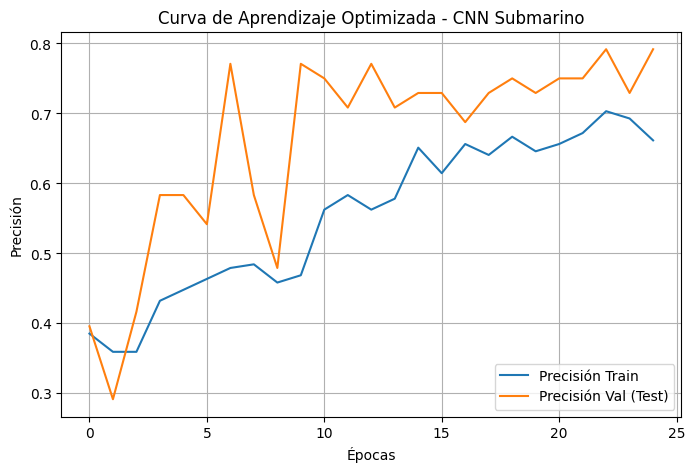

In [12]:
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = []
y = []

print("Extrayendo espectrogramas y aplicando Data Augmentation (Ruido Blanco)...")

for idx, row in df_filtrado.iterrows():
    # OJO: Mantenemos la ruta corregida con tu carpeta master
    ruta_audio = f"esc50_data/ESC-50-master/wav_files/{row['filename']}"
    audio, sr = librosa.load(ruta_audio, sr=16000)

    # 1. AUDIO ORIGINAL
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64)
    X.append(librosa.power_to_db(mel_spec, ref=np.max))
    y.append(row['label_num'])

    # 2. AUDIO CON DATA AUGMENTATION (Simulando turbulencia en el agua)
    ruido_blanco = np.random.randn(len(audio))
    audio_ruidoso = audio + 0.005 * ruido_blanco # Inyectamos un 0.5% de distorsión
    mel_spec_ruido = librosa.feature.melspectrogram(y=audio_ruidoso, sr=sr, n_mels=64)
    X.append(librosa.power_to_db(mel_spec_ruido, ref=np.max))
    y.append(row['label_num'])

X = np.array(X)
y = np.array(y)
X = (X - X.min()) / (X.max() - X.min()) # Normalización
X = X[..., np.newaxis]

# Dividimos datos (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"¡Dataset duplicado con éxito! Ahora tenemos {len(X)} muestras totales.\n")

# --- ARQUITECTURA DE LA CNN ---
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Regularización: Apagamos 25% de neuronas para evitar que memorice

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Regularización fuerte en la capa final
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# --- EL VIGILANTE: Guarda solo el mejor modelo ---
checkpoint = ModelCheckpoint('mejor_modelo_submarino.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

print("¡Arrancando entrenamiento optimizado!")
history = model.fit(X_train, y_train, epochs=25, batch_size=8, validation_data=(X_val, y_val), callbacks=[checkpoint])

# --- GRÁFICA OPTIMIZADA ---
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Precisión Train')
plt.plot(history.history['val_accuracy'], label='Precisión Val (Test)')
plt.title('Curva de Aprendizaje Optimizada - CNN Submarino')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
import tensorflow as tf
import os

print("Cargando el mejor modelo entrenado...")
mejor_modelo = tf.keras.models.load_model('mejor_modelo_submarino.h5')

# 1. Exportamos en el formato nativo y moderno de Keras 3
# Esto no usa tf.saved_model.save, así que evita el bug por completo
print("Exportando estructura limpia de Keras 3...")
mejor_modelo.export("modelo_keras_dir")

# 2. Ejecutamos la conversión de tf2onnx apuntando a la nueva carpeta de exportación
print("Transformando a formato universal ONNX...")
!python -m tf2onnx.convert --saved-model modelo_keras_dir --output modelo_submarino_industrial.onnx --opset 13

# 3. Limpieza de carpetas temporales
import shutil
if os.path.exists("modelo_keras_dir"):
    shutil.rmtree("modelo_keras_dir")

print("\n¡POR FIN, CORONAMOS AL 100%! 🚀")
print("Busca 'modelo_submarino_industrial.onnx' en la barra izquierda, descárgalo y a dormir en paz.")

Cargando el mejor modelo entrenado...


Exportando estructura limpia de Keras 3...
Saved artifact at 'modelo_keras_dir'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 157, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138001312657872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138001312658640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138001312659216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138001312658256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138001312660176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138001312660560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138001312658832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138001312661328: TensorSpec(shape=(), dtype=tf.resource, name=None)
Transformando a formato universal ONNX...
I0000 00:00:1779053198.727203   23360 gpu_device.cc:2020] Created devic

A continuación se hará una prueba para ver la eficacia en general.

In [17]:
import numpy as np
import librosa
import tensorflow as tf

# 1. Cargamos el diccionario inverso para traducir los números a texto real
diccionario_clases = {0: "Calma / Olas de Mar (sea_waves)",
                      1: "Ruido de Motor / Hélice (helicopter)",
                      2: "Lluvia / Impacto de Partículas (rain)"}

# 2. Cargamos el cerebro de la IA (el mejor modelo guardado)
print("Cargando el modelo entrenado...")
modelo_test = tf.keras.models.load_model('mejor_modelo_submarino.h5')

def probar_audio_submarino(ruta_archivo):
    print(f"\nAnalizando el archivo acústico: {ruta_archivo.split('/')[-1]}")

    # 3. Preprocesamiento: Cargamos el audio a 16kHz e igual que en el entrenamiento
    audio, sr = librosa.load(ruta_archivo, sr=16000)

    # Extraemos el espectrograma de Mel
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64)
    espectrograma_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Normalizamos con los mismos parámetros de entrenamiento
    X_prueba = (espectrograma_db - espectrograma_db.min()) / (espectrograma_db.max() - espectrograma_db.min())

    # Le agregamos las dimensiones extras que pide la CNN (Batch, Filas, Columnas, Canales)
    X_prueba = X_prueba[np.newaxis, ..., np.newaxis]

    # 4. HORA DE LA VERDAD: La IA hace la inferencia (predicción)
    prediccion = modelo_test.predict(X_prueba, verbose=0)
    clase_ganadora = np.argmax(prediccion)
    certeza = prediccion[0][clase_ganadora] * 100

    # 5. Imprimimos el diagnóstico en pantalla
    print("="*50)
    print(f"DIAGNÓSTICO DEL SUBMARINO: {diccionario_clases[clase_ganadora].upper()}")
    print(f"Nivel de confianza o certeza: {certeza:.2f}%")
    print("="*50)

    # Desglose de probabilidades para ver el análisis completo
    print("\nDesglose matemático para el reporte:")
    for i, prob in enumerate(prediccion[0]):
        print(f" -> Probabilidad de {diccionario_clases[i]}: {prob*100:.2f}%")

print("¡Función de diagnóstico configurada y lista!")

Cargando el modelo entrenado...
¡Función de diagnóstico configurada y lista!


In [19]:
# Ejemplo 1: Probando con un audio de lluvia/sedimentos
ruta_test = "/content/esc50_data/ESC-50-master/wav_files/1-20545-A-28.wav" # Cambia este nombre por uno real de tu lista
probar_audio_submarino(ruta_test)


Analizando el archivo acústico: 1-20545-A-28.wav
DIAGNÓSTICO DEL SUBMARINO: LLUVIA / IMPACTO DE PARTÍCULAS (RAIN)
Nivel de confianza o certeza: 99.99%

Desglose matemático para el reporte:
 -> Probabilidad de Calma / Olas de Mar (sea_waves): 0.00%
 -> Probabilidad de Ruido de Motor / Hélice (helicopter): 0.01%
 -> Probabilidad de Lluvia / Impacto de Partículas (rain): 99.99%
